#### Tâche 1 — Chargement & audit initial du dataset

In [1]:
import pandas as pd
import numpy as np

# Chargement
df = pd.read_csv("StudentPerformanceFactors.csv")

# ── 1. Dimensions ──────────────────────────────────────────
print("=" * 50)
print(f"Dimensions : {df.shape[0]} lignes × {df.shape[1]} colonnes")

# ── 2. Aperçu des premières lignes ─────────────────────────
print("\n── Head (5 premières lignes) ──")
print(df.head())

Dimensions : 6607 lignes × 20 colonnes

── Head (5 premières lignes) ──
   Hours_Studied  Attendance Parental_Involvement Access_to_Resources  \
0             23          84                  Low                High   
1             19          64                  Low              Medium   
2             24          98               Medium              Medium   
3             29          89                  Low              Medium   
4             19          92               Medium              Medium   

  Extracurricular_Activities  Sleep_Hours  Previous_Scores Motivation_Level  \
0                         No            7               73              Low   
1                         No            8               59              Low   
2                        Yes            7               91           Medium   
3                        Yes            8               98           Medium   
4                        Yes            6               65           Medium   

  Internet_Acc

- Types de chaque colonne

In [2]:
print("\n── Types des colonnes ──")
print(df.dtypes)


── Types des colonnes ──
Hours_Studied                 int64
Attendance                    int64
Parental_Involvement            str
Access_to_Resources             str
Extracurricular_Activities      str
Sleep_Hours                   int64
Previous_Scores               int64
Motivation_Level                str
Internet_Access                 str
Tutoring_Sessions             int64
Family_Income                   str
Teacher_Quality                 str
School_Type                     str
Peer_Influence                  str
Physical_Activity             int64
Learning_Disabilities           str
Parental_Education_Level        str
Distance_from_Home              str
Gender                          str
Exam_Score                    int64
dtype: object


- Statistiques descriptives

In [3]:
print("\n── Statistiques descriptives ──")
print(df.describe(include="all").T)


── Statistiques descriptives ──
                             count unique          top  freq       mean  \
Hours_Studied               6607.0    NaN          NaN   NaN  19.975329   
Attendance                  6607.0    NaN          NaN   NaN  79.977448   
Parental_Involvement          6607      3       Medium  3362        NaN   
Access_to_Resources           6607      3       Medium  3319        NaN   
Extracurricular_Activities    6607      2          Yes  3938        NaN   
Sleep_Hours                 6607.0    NaN          NaN   NaN    7.02906   
Previous_Scores             6607.0    NaN          NaN   NaN  75.070531   
Motivation_Level              6607      3       Medium  3351        NaN   
Internet_Access               6607      2          Yes  6108        NaN   
Tutoring_Sessions           6607.0    NaN          NaN   NaN   1.493719   
Family_Income                 6607      3          Low  2672        NaN   
Teacher_Quality               6529      3       Medium  3925       

- Valeurs manquantes

In [4]:
print("\n── Valeurs manquantes par colonne ──")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    "Manquants": missing,
    "Pourcentage (%)": missing_pct
}).query("Manquants > 0")

print(missing_df if not missing_df.empty else "✅ Aucune valeur manquante détectée")


── Valeurs manquantes par colonne ──
                          Manquants  Pourcentage (%)
Teacher_Quality                  78             1.18
Parental_Education_Level         90             1.36
Distance_from_Home               67             1.01


- Valeurs uniques pour les catégorielles

In [5]:
print("\n── Valeurs uniques (colonnes catégorielles) ──")
cat_cols = df.select_dtypes(include="object").columns
for col in cat_cols:
    print(f"  {col} : {df[col].unique()}")


── Valeurs uniques (colonnes catégorielles) ──
  Parental_Involvement : <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Access_to_Resources : <ArrowStringArray>
['High', 'Medium', 'Low']
Length: 3, dtype: str
  Extracurricular_Activities : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  Motivation_Level : <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Internet_Access : <ArrowStringArray>
['Yes', 'No']
Length: 2, dtype: str
  Family_Income : <ArrowStringArray>
['Low', 'Medium', 'High']
Length: 3, dtype: str
  Teacher_Quality : <ArrowStringArray>
['Medium', 'High', 'Low', nan]
Length: 4, dtype: str
  School_Type : <ArrowStringArray>
['Public', 'Private']
Length: 2, dtype: str
  Peer_Influence : <ArrowStringArray>
['Positive', 'Negative', 'Neutral']
Length: 3, dtype: str
  Learning_Disabilities : <ArrowStringArray>
['No', 'Yes']
Length: 2, dtype: str
  Parental_Education_Level : <ArrowStringArray>
['High School', 'College', 'Postgraduat

C:\Users\pc\AppData\Local\Temp\ipykernel_1160\1233230527.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include="object").columns


#### Tâche 2 —  EDA Univariée 

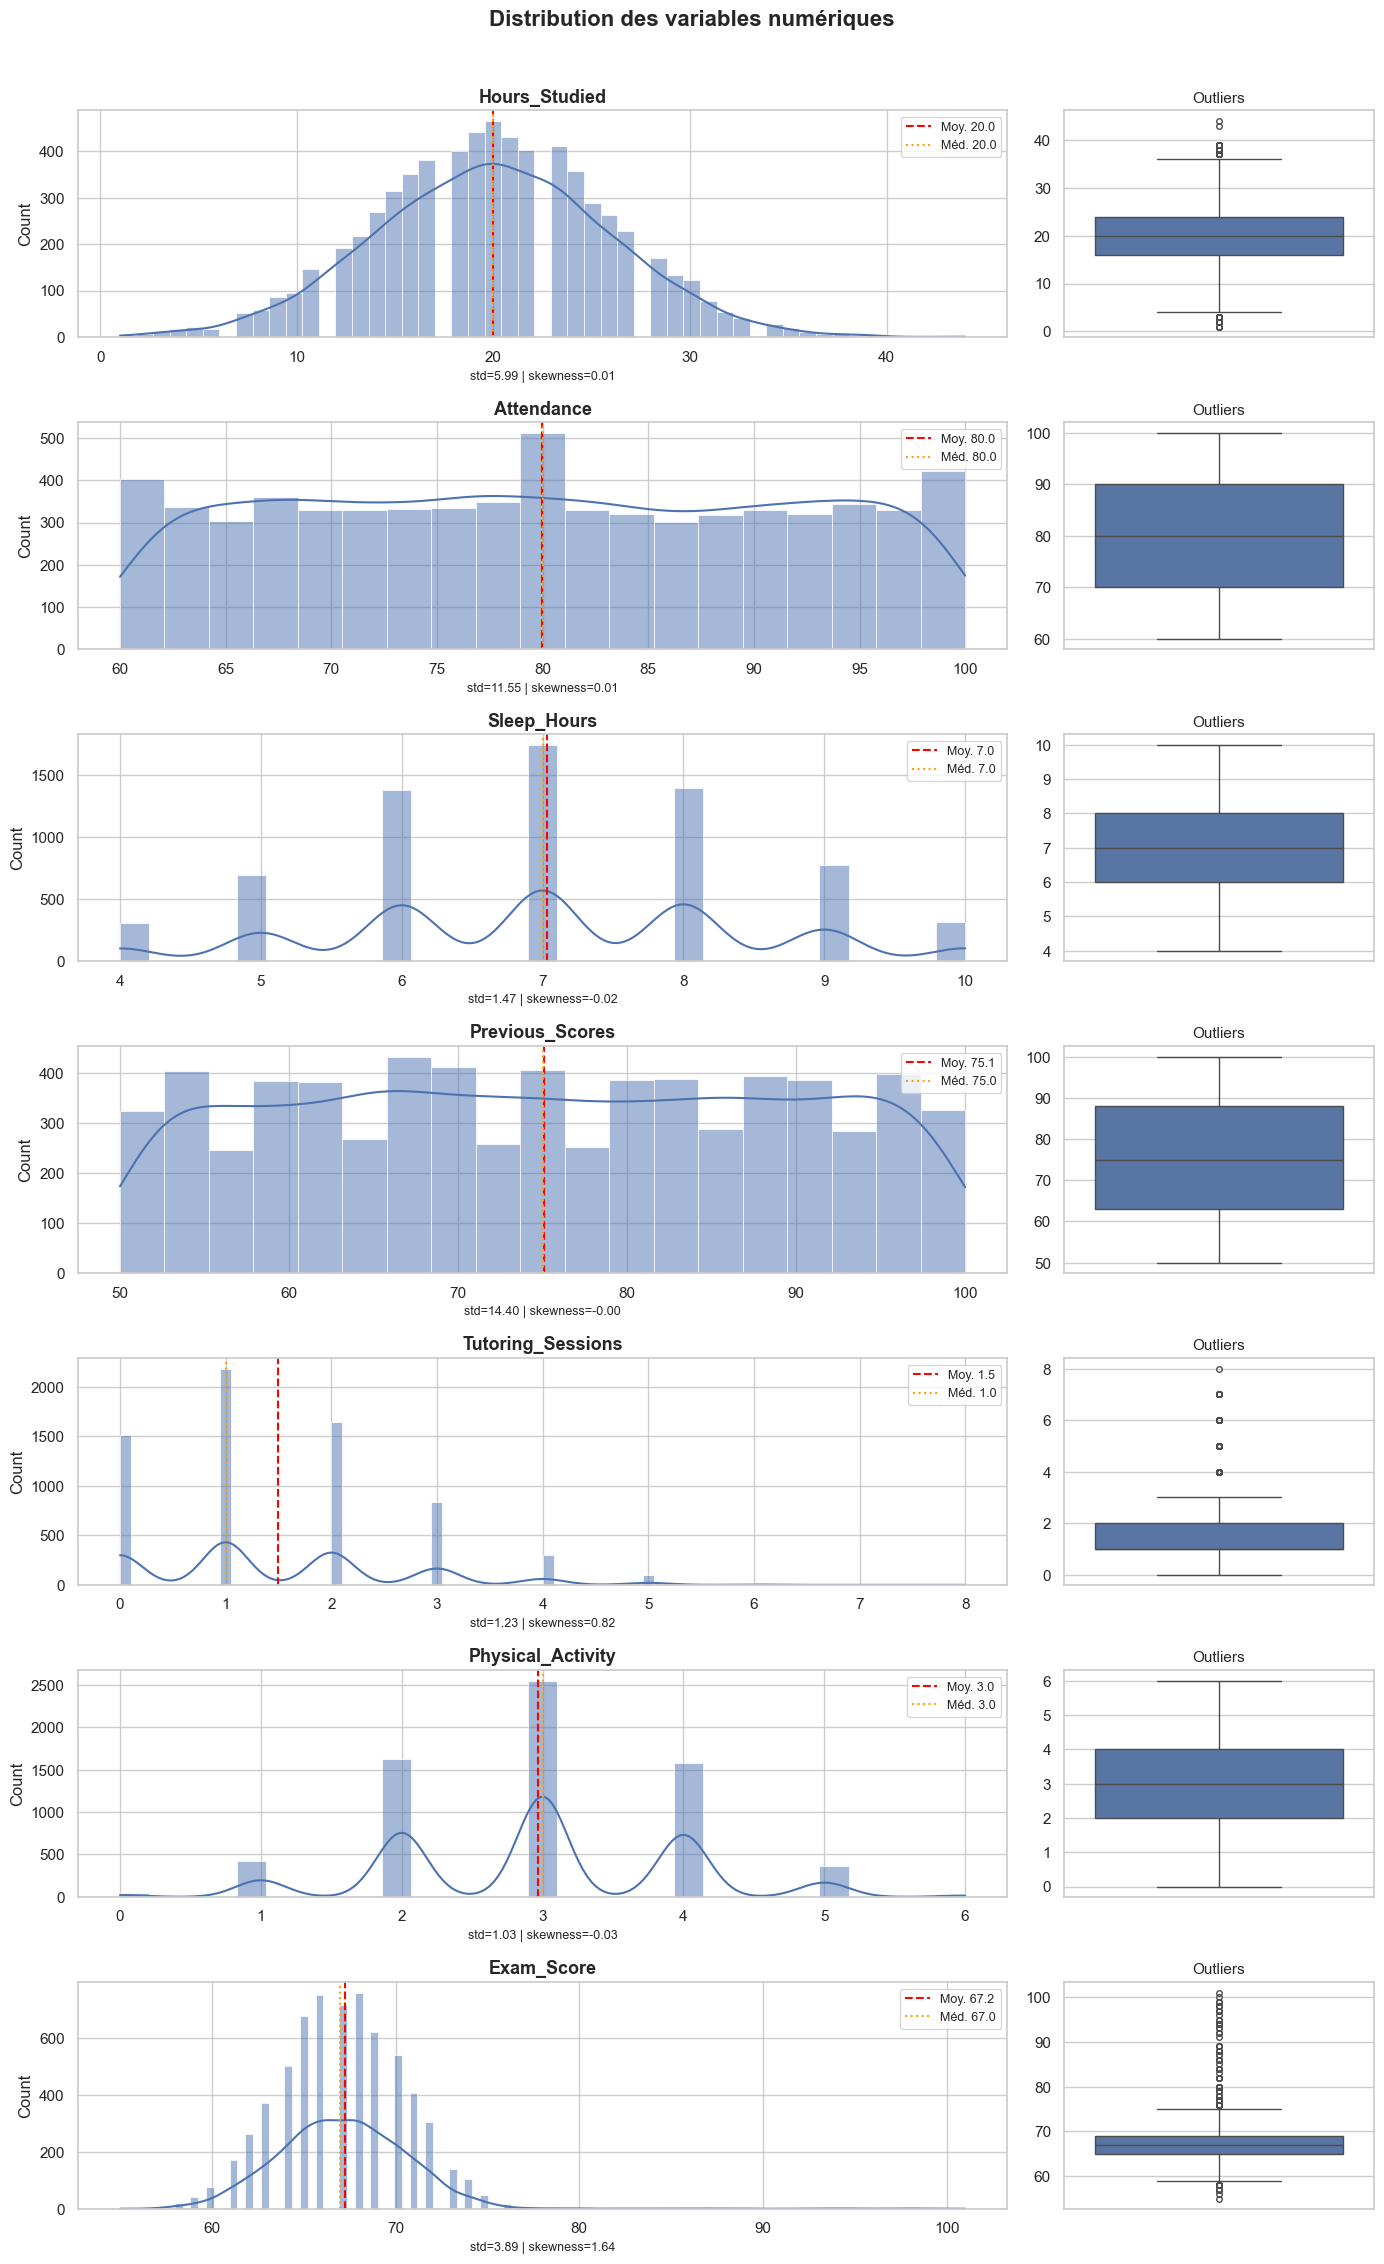

✅ Figure 1 sauvegardée : eda_numeriques.png


In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("StudentPerformanceFactors.csv")

# ── Palette & style ────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted")
COLOR_NUM = "#4C72B0"   # bleu pour numériques
COLOR_CAT = "#55A868"   # vert pour catégorielles

# ══════════════════════════════════════════════════════════
# PARTIE 1 — Variables NUMÉRIQUES (histogramme + KDE + boxplot)
# ══════════════════════════════════════════════════════════
num_cols = ["Hours_Studied", "Attendance", "Sleep_Hours",
            "Previous_Scores", "Tutoring_Sessions",
            "Physical_Activity", "Exam_Score"]

fig, axes = plt.subplots(len(num_cols), 2,
                         figsize=(14, len(num_cols) * 3.2),
                         gridspec_kw={"width_ratios": [3, 1]})
fig.suptitle("Distribution des variables numériques", fontsize=16, fontweight="bold", y=1.01)

for i, col in enumerate(num_cols):
    ax_hist = axes[i, 0]
    ax_box  = axes[i, 1]

    # Histogramme + KDE
    sns.histplot(df[col].dropna(), kde=True, ax=ax_hist,
                 color=COLOR_NUM, edgecolor="white", linewidth=0.5)
    ax_hist.axvline(df[col].mean(),   color="red",    linestyle="--",
                    linewidth=1.5, label=f"Moy. {df[col].mean():.1f}")
    ax_hist.axvline(df[col].median(), color="orange", linestyle=":",
                    linewidth=1.5, label=f"Méd. {df[col].median():.1f}")
    ax_hist.set_title(col, fontsize=13, fontweight="bold")
    ax_hist.set_xlabel("")
    ax_hist.legend(fontsize=9)

    # Boxplot (détection outliers)
    sns.boxplot(y=df[col].dropna(), ax=ax_box, color=COLOR_NUM,
                flierprops=dict(marker="o", color="red", markersize=4))
    ax_box.set_title("Outliers", fontsize=11)
    ax_box.set_ylabel("")

    # Stats dans le titre
    skew = df[col].skew()
    ax_hist.set_xlabel(
        f"std={df[col].std():.2f} | skewness={skew:.2f}", fontsize=9)

plt.tight_layout()
plt.savefig("eda_numeriques.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 1 sauvegardée : eda_numeriques.png")



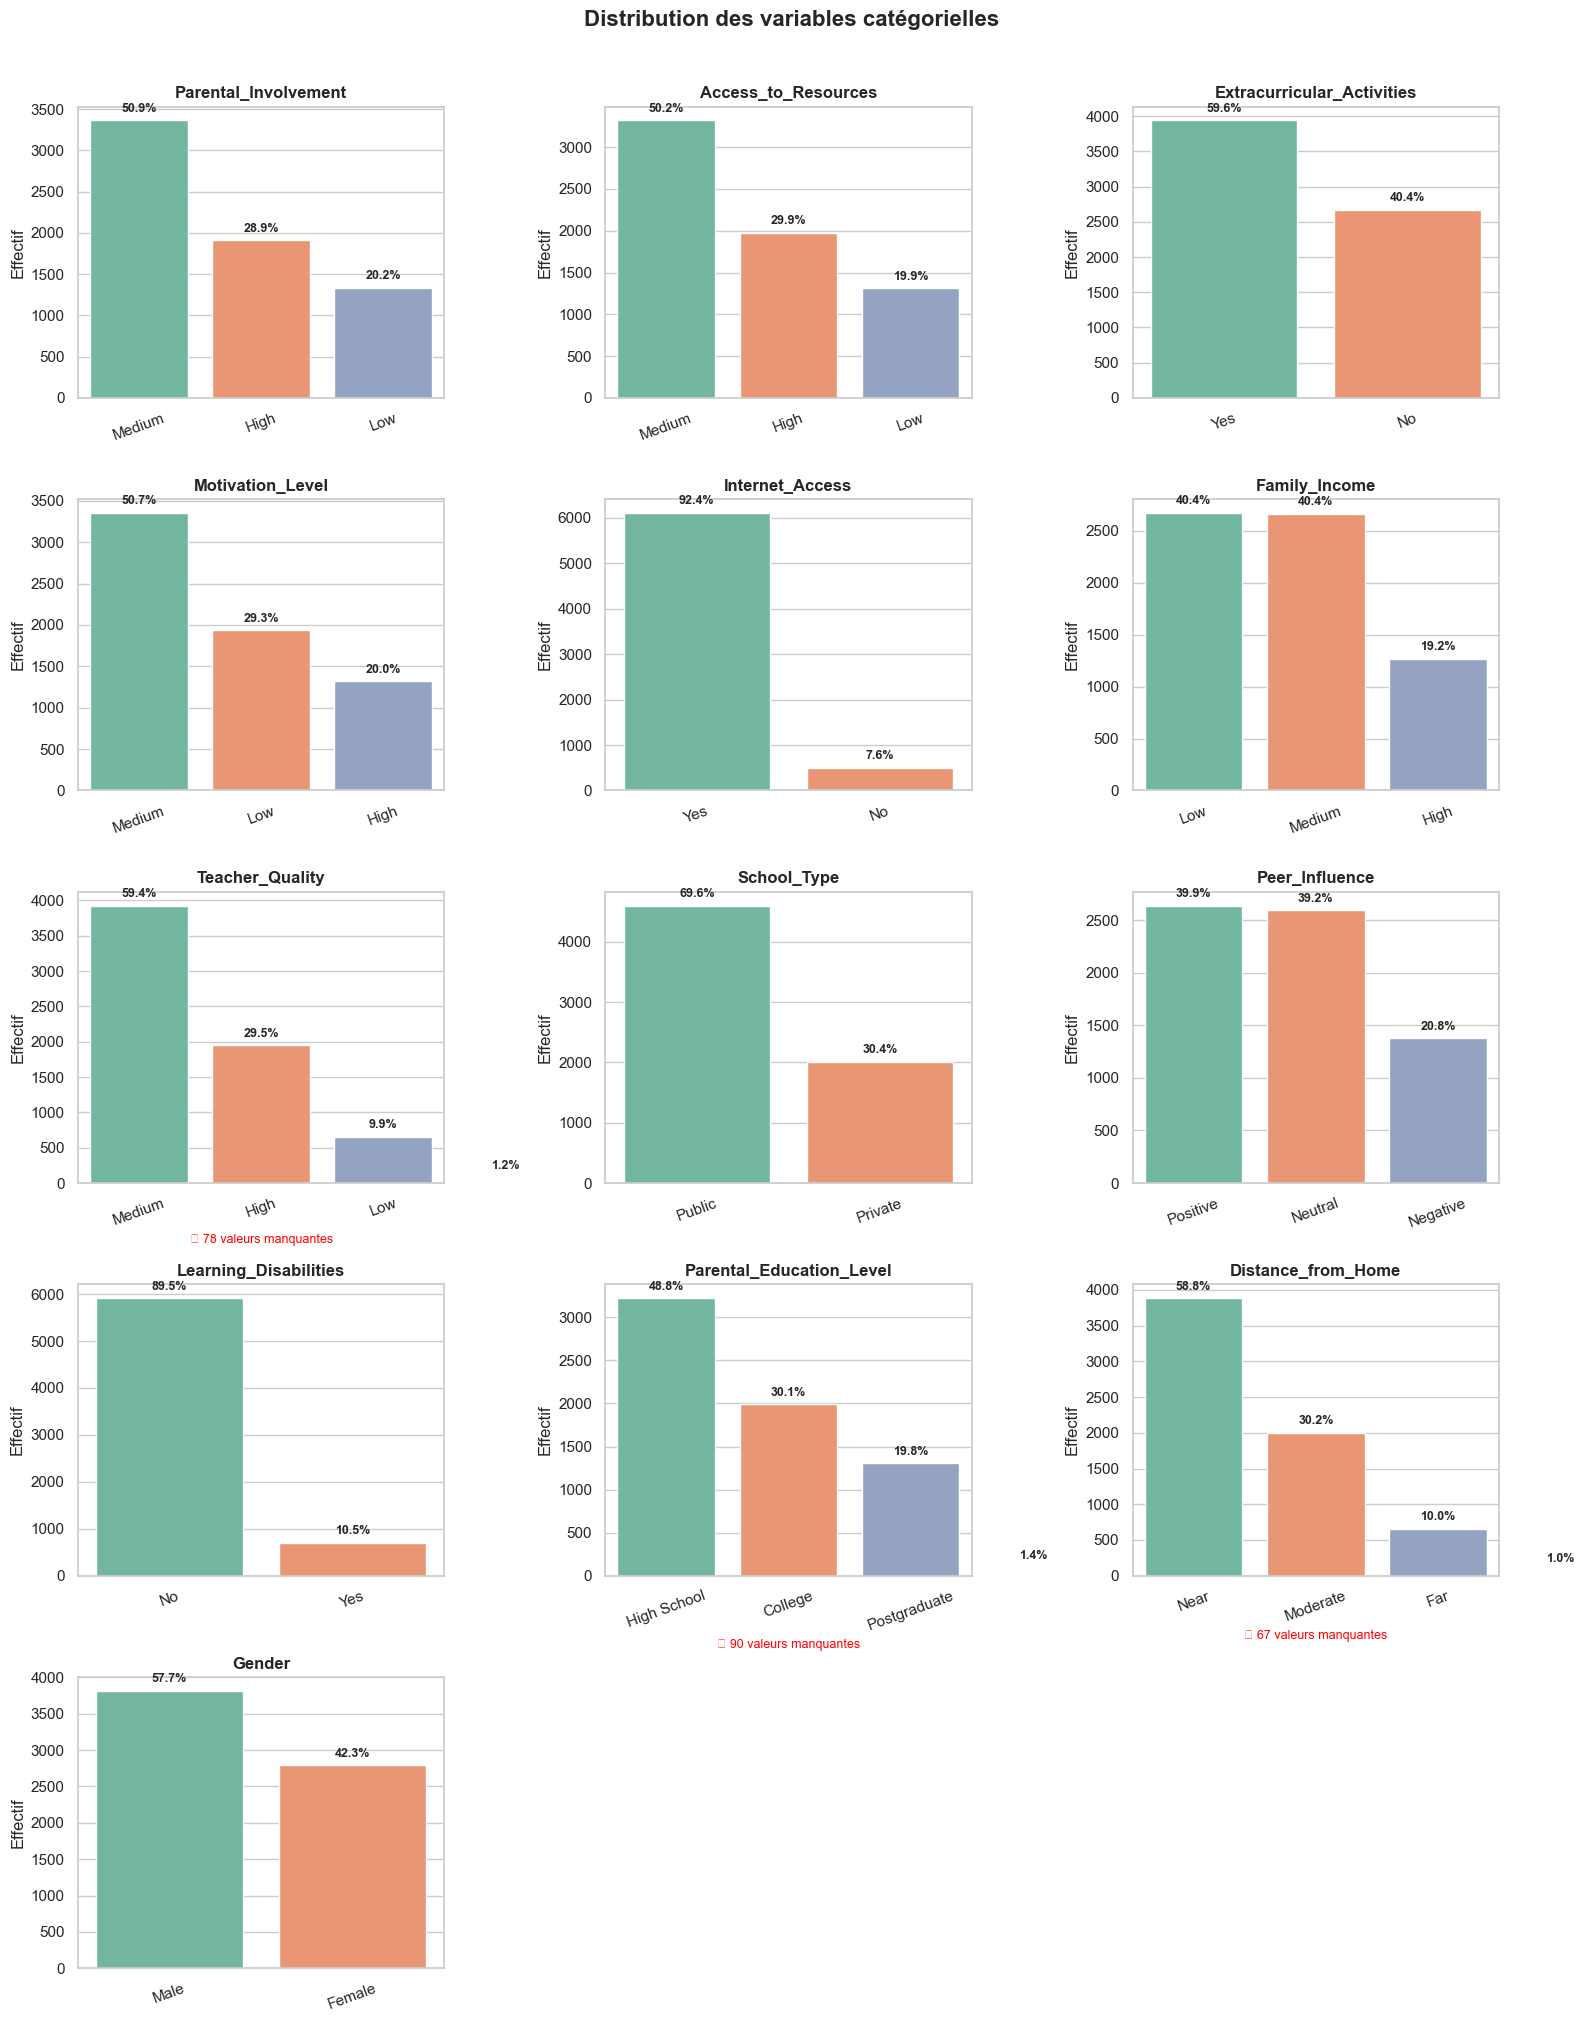

✅ Figure 2 sauvegardée : eda_categorielles.png


In [7]:
# ══════════════════════════════════════════════════════════
# PARTIE 2 — Variables CATÉGORIELLES (barplots comptages + %)
# ══════════════════════════════════════════════════════════
cat_cols = ["Parental_Involvement", "Access_to_Resources",
            "Extracurricular_Activities", "Motivation_Level",
            "Internet_Access", "Family_Income", "Teacher_Quality",
            "School_Type", "Peer_Influence", "Learning_Disabilities",
            "Parental_Education_Level", "Distance_from_Home", "Gender"]

n_cols_grid = 3
n_rows_grid = (len(cat_cols) + n_cols_grid - 1) // n_cols_grid

fig2, axes2 = plt.subplots(n_rows_grid, n_cols_grid,
                           figsize=(16, n_rows_grid * 4))
fig2.suptitle("Distribution des variables catégorielles", fontsize=16,
              fontweight="bold", y=1.01)
axes2 = axes2.flatten()

for i, col in enumerate(cat_cols):
    ax = axes2[i]
    counts = df[col].value_counts(dropna=False)
    pcts   = df[col].value_counts(normalize=True, dropna=False) * 100

    bars = sns.barplot(x=counts.index.astype(str), y=counts.values,
                       ax=ax, palette="Set2", edgecolor="white")

    # Ajouter % sur chaque barre
    for j, (cnt, pct) in enumerate(zip(counts.values, pcts.values)):
        ax.text(j, cnt + max(counts.values)*0.02,
                f"{pct:.1f}%", ha="center", va="bottom", fontsize=9,
                fontweight="bold")

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Effectif")
    ax.tick_params(axis="x", rotation=20)

    # Signaler les NA s'il y en a
    n_na = df[col].isna().sum()
    if n_na > 0:
        ax.set_xlabel(f"⚠ {n_na} valeurs manquantes", fontsize=9,
                      color="red")

# Masquer les axes vides
for j in range(len(cat_cols), len(axes2)):
    axes2[j].set_visible(False)

plt.tight_layout()
plt.savefig("eda_categorielles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure 2 sauvegardée : eda_categorielles.png")


In [8]:
# ══════════════════════════════════════════════════════════
# PARTIE 3 — Résumé texte des outliers (IQR method)
# ══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("RÉSUMÉ OUTLIERS — méthode IQR (×1.5)")
print("="*55)
for col in num_cols:
    Q1  = df[col].quantile(0.25)
    Q3  = df[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high= Q3 + 1.5 * IQR
    outliers = df[(df[col] < low) | (df[col] > high)][col]
    pct = len(outliers)/len(df)*100
    print(f"{col:25s} → {len(outliers):4d} outliers ({pct:.2f}%)"
          f"  [bornes: {low:.1f} – {high:.1f}]")


RÉSUMÉ OUTLIERS — méthode IQR (×1.5)
Hours_Studied             →   43 outliers (0.65%)  [bornes: 4.0 – 36.0]
Attendance                →    0 outliers (0.00%)  [bornes: 40.0 – 120.0]
Sleep_Hours               →    0 outliers (0.00%)  [bornes: 3.0 – 11.0]
Previous_Scores           →    0 outliers (0.00%)  [bornes: 25.5 – 125.5]
Tutoring_Sessions         →  430 outliers (6.51%)  [bornes: -0.5 – 3.5]
Physical_Activity         →    0 outliers (0.00%)  [bornes: -1.0 – 7.0]
Exam_Score                →  104 outliers (1.57%)  [bornes: 59.0 – 75.0]


#### Tache 3 : Analyse exploratoire bivariée & corrélations

- Partie 1 : Matrice de corrélation

CORRÉLATIONS AVEC Exam_Score (triées)
Attendance                +0.5811  █████████████████
Hours_Studied             +0.4455  █████████████
Previous_Scores           +0.1751  █████
Tutoring_Sessions         +0.1565  ████
Physical_Activity         +0.0278  
Sleep_Hours               -0.0170  


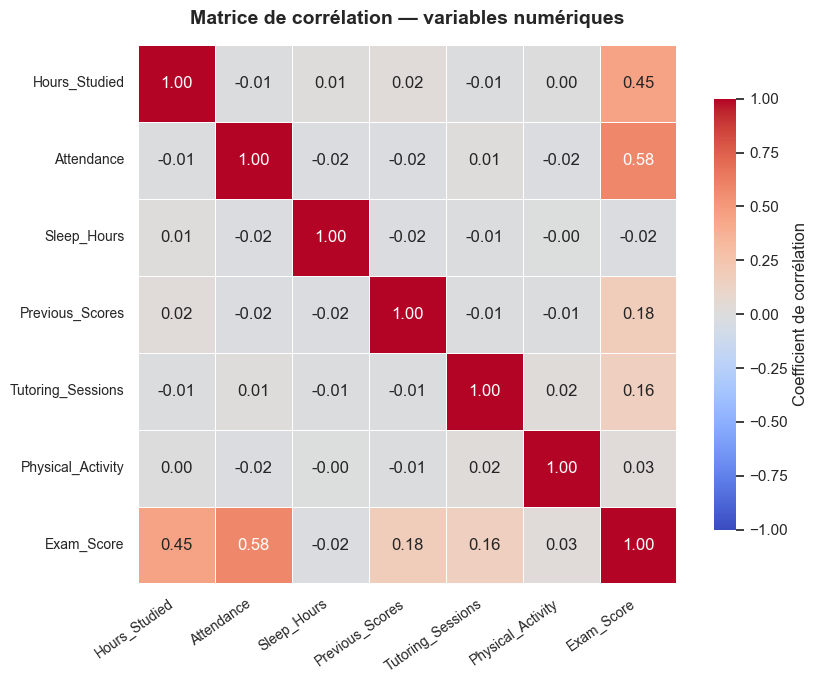

✅ Heatmap sauvegardée


In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
warnings.filterwarnings("ignore")

df = pd.read_csv("StudentPerformanceFactors.csv")

# ══════════════════════════════════════════════════════════
# PARTIE 1 — MATRICE DE CORRÉLATION
# ══════════════════════════════════════════════════════════

num_cols = ["Hours_Studied", "Attendance", "Sleep_Hours",
            "Previous_Scores", "Tutoring_Sessions",
            "Physical_Activity", "Exam_Score"]

corr_matrix = df[num_cols].corr()

# ── Affichage du tableau des corrélations avec Exam_Score ──
print("=" * 50)
print("CORRÉLATIONS AVEC Exam_Score (triées)")
print("=" * 50)
corr_target = corr_matrix["Exam_Score"].drop("Exam_Score").sort_values(ascending=False)
for var, val in corr_target.items():
    bar = "█" * int(abs(val) * 30)
    signe = "+" if val > 0 else "-"
    print(f"{var:25s} {signe}{abs(val):.4f}  {bar}")

# ── Heatmap ────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 7))

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5,
    linecolor="white",
    square=True,
    ax=ax,
    cbar_kws={"shrink": 0.8, "label": "Coefficient de corrélation"}
)

ax.set_title("Matrice de corrélation — variables numériques",
             fontsize=14, fontweight="bold", pad=15)
ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha="right", fontsize=10)
ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=10)

plt.tight_layout()
plt.savefig("heatmap_correlation.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Heatmap sauvegardée")

-  Partie 2 : Boxplots croisés

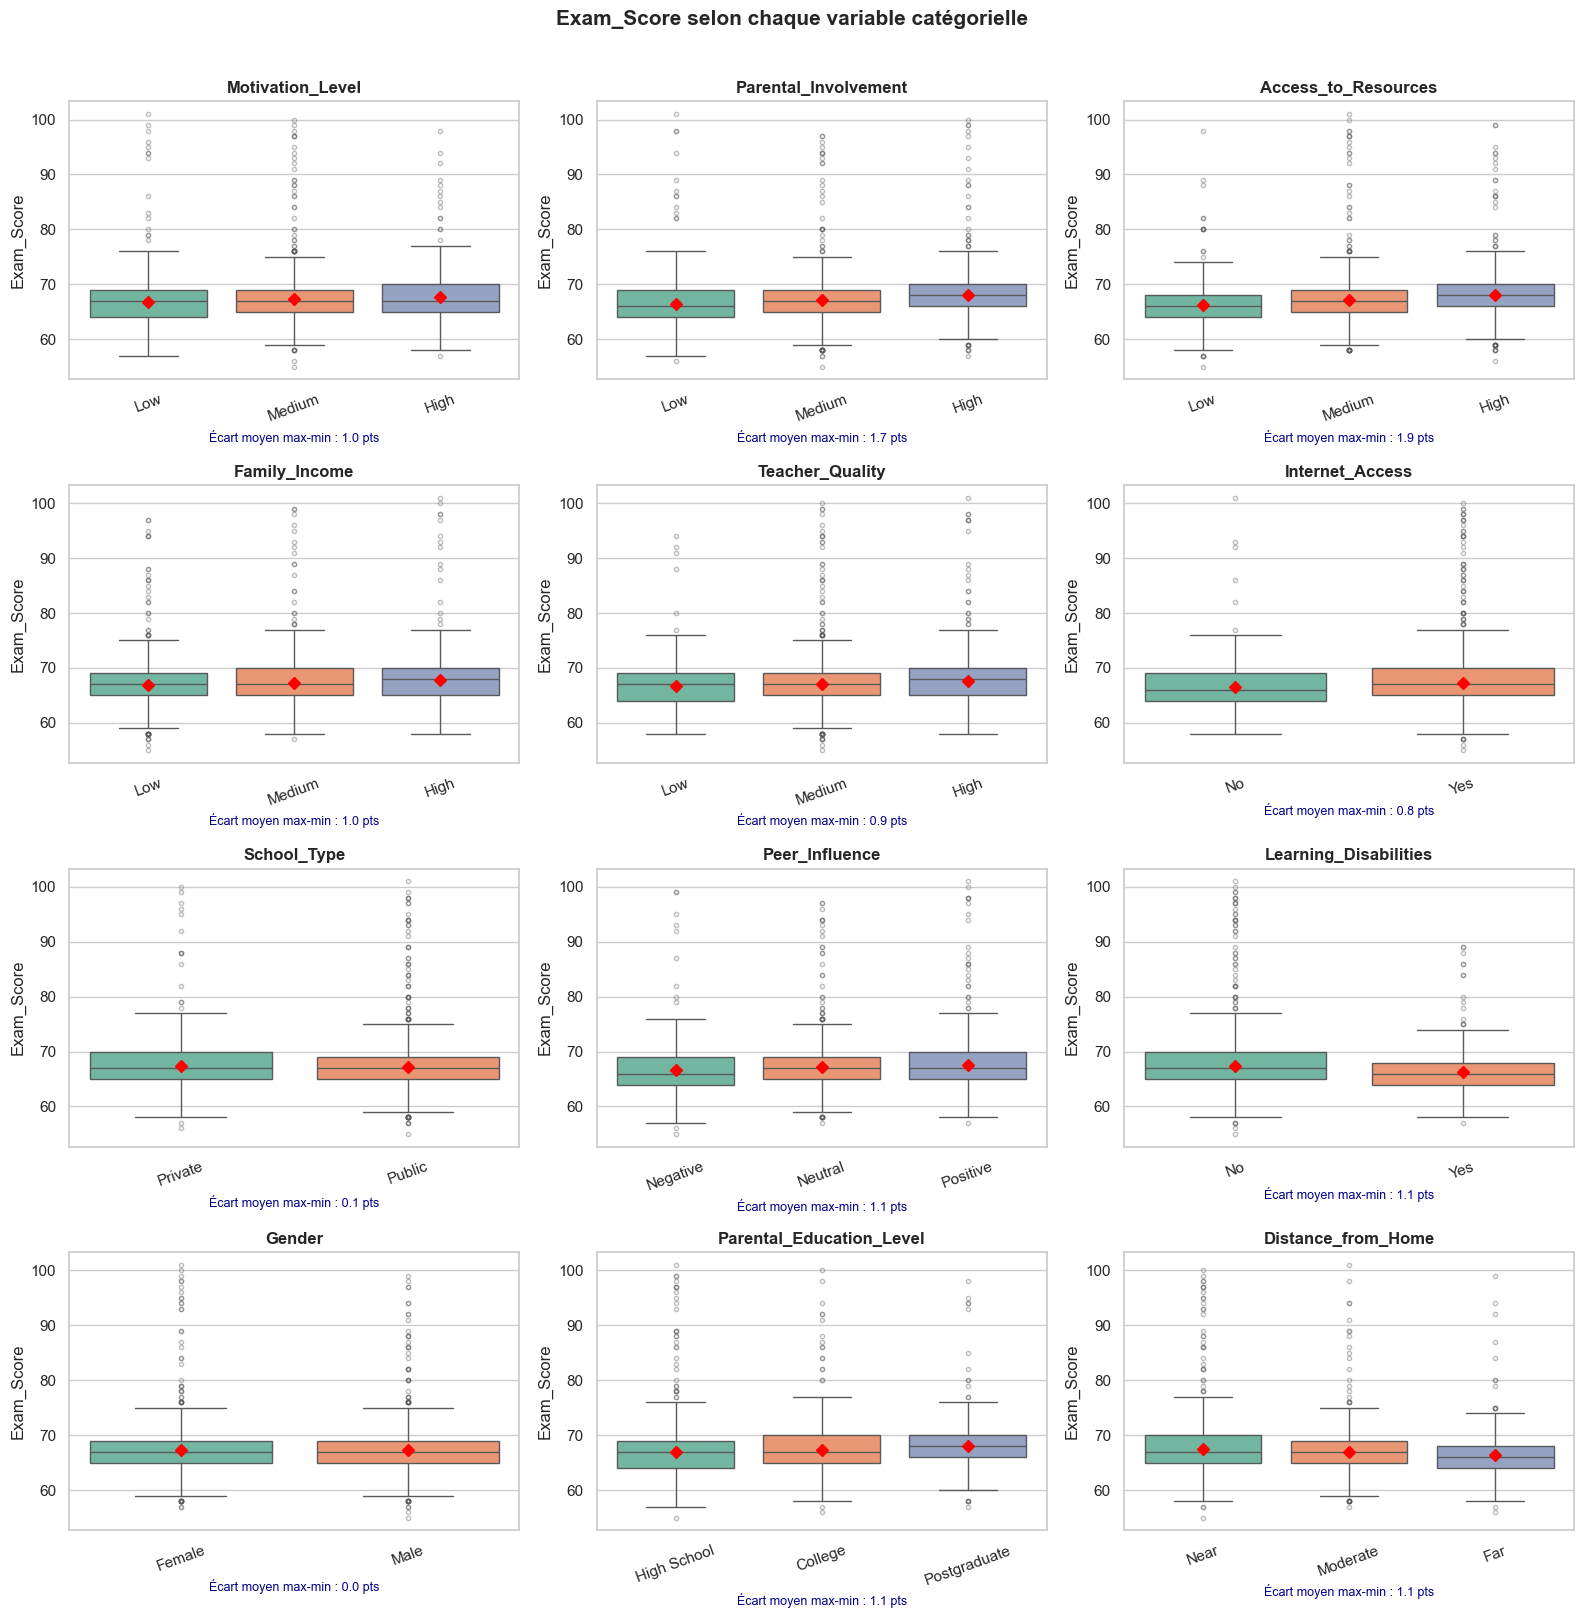

✅ Boxplots catégorielles sauvegardés


In [10]:
# ══════════════════════════════════════════════════════════
# PARTIE 2 — BOXPLOTS CROISÉS (catégorielles vs Exam_Score)
# ══════════════════════════════════════════════════════════

cat_cols_plot = [
    "Motivation_Level", "Parental_Involvement",
    "Access_to_Resources", "Family_Income",
    "Teacher_Quality", "Internet_Access",
    "School_Type", "Peer_Influence",
    "Learning_Disabilities", "Gender",
    "Parental_Education_Level", "Distance_from_Home"
]

# Ordre logique pour les ordinales
ordre = {
    "Motivation_Level":        ["Low", "Medium", "High"],
    "Parental_Involvement":    ["Low", "Medium", "High"],
    "Access_to_Resources":     ["Low", "Medium", "High"],
    "Family_Income":           ["Low", "Medium", "High"],
    "Teacher_Quality":         ["Low", "Medium", "High"],
    "Parental_Education_Level":["High School", "College", "Postgraduate"],
    "Distance_from_Home":      ["Near", "Moderate", "Far"],
}

n_cols_g = 3
n_rows_g = (len(cat_cols_plot) + n_cols_g - 1) // n_cols_g

fig2, axes2 = plt.subplots(n_rows_g, n_cols_g,
                            figsize=(16, n_rows_g * 4))
fig2.suptitle("Exam_Score selon chaque variable catégorielle",
              fontsize=15, fontweight="bold", y=1.01)
axes2 = axes2.flatten()

for i, col in enumerate(cat_cols_plot):
    ax = axes2[i]
    order = ordre.get(col, sorted(df[col].dropna().unique()))

    sns.boxplot(
        data=df, x=col, y="Exam_Score",
        order=order, palette="Set2",
        ax=ax,
        flierprops=dict(marker="o", color="red",
                        markersize=3, alpha=0.4)
    )

    # Ajouter la moyenne par groupe
    means = df.groupby(col)["Exam_Score"].mean()
    for j, cat in enumerate(order):
        if cat in means.index:
            ax.plot(j, means[cat], marker="D",
                    color="red", markersize=6, zorder=5)

    ax.set_title(col, fontsize=12, fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("Exam_Score")
    ax.tick_params(axis="x", rotation=20)

    # Annoter la différence max-min entre groupes
    grp_means = [means.get(c, np.nan) for c in order if c in means.index]
    if len(grp_means) >= 2:
        diff = max(grp_means) - min(grp_means)
        ax.set_xlabel(f"Écart moyen max-min : {diff:.1f} pts",
                      fontsize=9, color="darkblue")

for j in range(len(cat_cols_plot), len(axes2)):
    axes2[j].set_visible(False)

plt.tight_layout()
plt.savefig("boxplots_categorielles.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Boxplots catégorielles sauvegardés")

- Partie 3 : Scatterplots

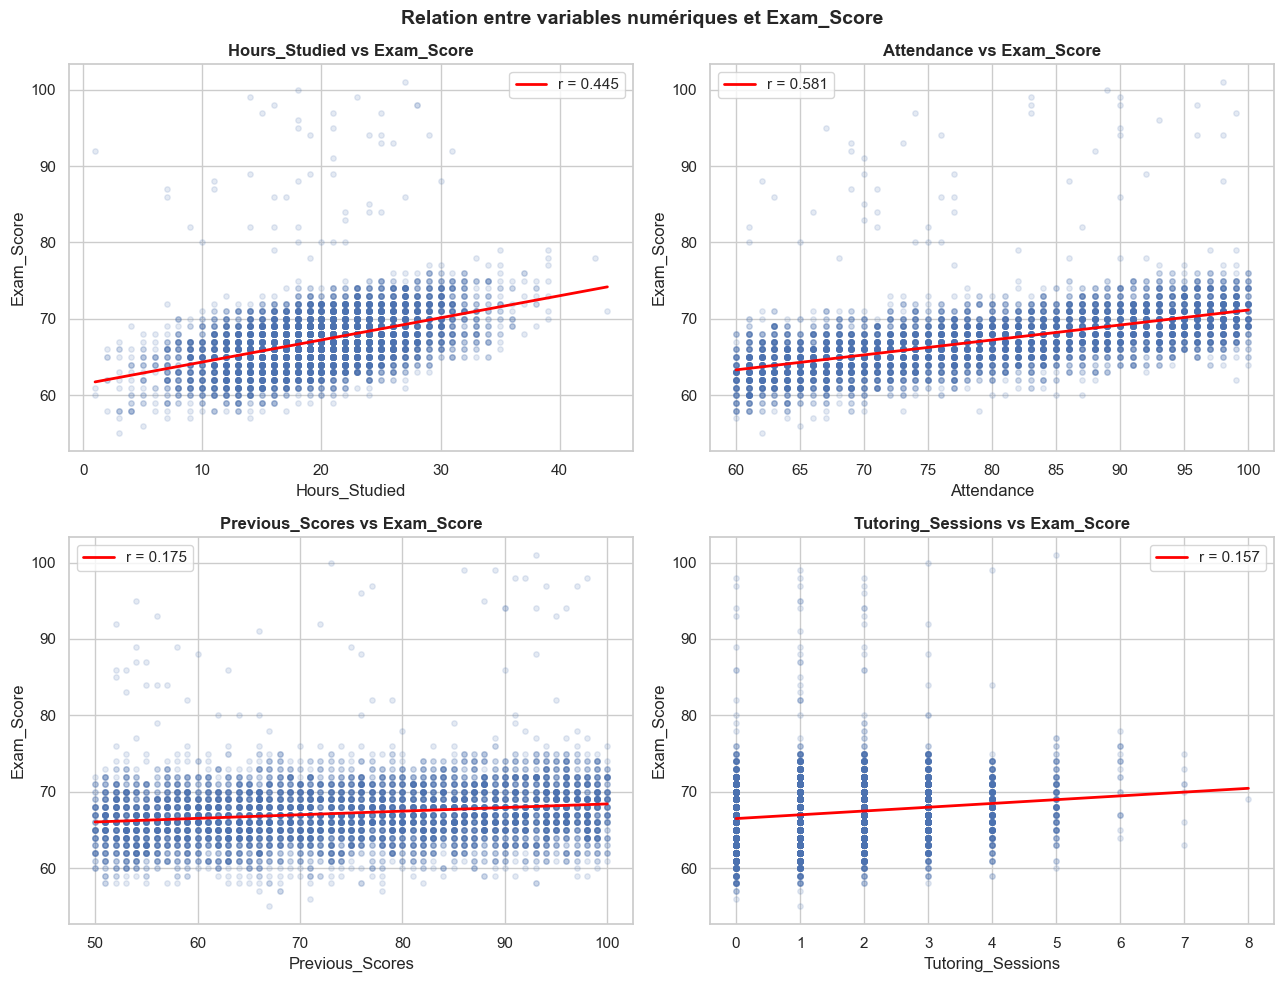

✅ Scatterplots sauvegardés

RÉSUMÉ — Variables les plus corrélées à Exam_Score
Attendance           0.581072
Hours_Studied        0.445455
Previous_Scores      0.175079
Tutoring_Sessions    0.156525
Physical_Activity    0.027824
Sleep_Hours         -0.017022


In [11]:
# ══════════════════════════════════════════════════════════
# PARTIE 3 — SCATTERPLOTS (numériques vs Exam_Score)
# ══════════════════════════════════════════════════════════

top_num = ["Hours_Studied", "Attendance",
           "Previous_Scores", "Tutoring_Sessions"]

fig3, axes3 = plt.subplots(2, 2, figsize=(13, 10))
fig3.suptitle("Relation entre variables numériques et Exam_Score",
              fontsize=14, fontweight="bold")
axes3 = axes3.flatten()

for i, col in enumerate(top_num):
    ax = axes3[i]
    corr_val = df[[col, "Exam_Score"]].corr().iloc[0, 1]

    ax.scatter(df[col], df["Exam_Score"],
               alpha=0.15, s=15, color="#4C72B0")

    # Droite de régression
    z = np.polyfit(df[col].dropna(),
                   df.loc[df[col].notna(), "Exam_Score"], 1)
    p = np.poly1d(z)
    x_line = np.linspace(df[col].min(), df[col].max(), 200)
    ax.plot(x_line, p(x_line), color="red",
            linewidth=2, label=f"r = {corr_val:.3f}")

    ax.set_title(f"{col} vs Exam_Score",
                 fontsize=12, fontweight="bold")
    ax.set_xlabel(col)
    ax.set_ylabel("Exam_Score")
    ax.legend(fontsize=11)

plt.tight_layout()
plt.savefig("scatterplots_numeriques.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Scatterplots sauvegardés")

# ══════════════════════════════════════════════════════════
# RÉSUMÉ FINAL — top variables corrélées
# ══════════════════════════════════════════════════════════
print("\n" + "="*55)
print("RÉSUMÉ — Variables les plus corrélées à Exam_Score")
print("="*55)
print(corr_target.to_string())

#### Tâche 4 — Gestion des valeurs manquantes

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.impute import SimpleImputer
import warnings
warnings.filterwarnings("ignore")

df = pd.read_csv("StudentPerformanceFactors.csv")

# ══════════════════════════════════════════════════════════
# ÉTAPE 1 — Diagnostic avant imputation
# ══════════════════════════════════════════════════════════
print("=" * 55)
print("AVANT IMPUTATION — Valeurs manquantes")
print("=" * 55)

cols_na = ["Teacher_Quality", "Parental_Education_Level", "Distance_from_Home"]

for col in cols_na:
    n_na  = df[col].isna().sum()
    pct   = n_na / len(df) * 100
    mode  = df[col].mode()[0]
    print(f"\n{col}")
    print(f"  Manquants     : {n_na} ({pct:.2f}%)")
    print(f"  Mode (→ valeur d'imputation) : '{mode}'")
    print(f"  Distribution  :\n{df[col].value_counts(dropna=True).to_string()}")

AVANT IMPUTATION — Valeurs manquantes

Teacher_Quality
  Manquants     : 78 (1.18%)
  Mode (→ valeur d'imputation) : 'Medium'
  Distribution  :
Teacher_Quality
Medium    3925
High      1947
Low        657

Parental_Education_Level
  Manquants     : 90 (1.36%)
  Mode (→ valeur d'imputation) : 'High School'
  Distribution  :
Parental_Education_Level
High School     3223
College         1989
Postgraduate    1305

Distance_from_Home
  Manquants     : 67 (1.01%)
  Mode (→ valeur d'imputation) : 'Near'
  Distribution  :
Distance_from_Home
Near        3884
Moderate    1998
Far          658


In [13]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 2 — Imputation par mode (SimpleImputer)
# ══════════════════════════════════════════════════════════
imputer = SimpleImputer(strategy="most_frequent")
df[cols_na] = imputer.fit_transform(df[cols_na])

In [14]:

# ══════════════════════════════════════════════════════════
# ÉTAPE 3 — Vérification après imputation
# ══════════════════════════════════════════════════════════
print("\n" + "=" * 55)
print("APRÈS IMPUTATION — Vérification")
print("=" * 55)

remaining_na = df.isnull().sum().sum()
print(f"\nTotal valeurs manquantes restantes : {remaining_na}")

for col in cols_na:
    print(f"\n{col} — distribution après imputation :")
    print(df[col].value_counts().to_string())



APRÈS IMPUTATION — Vérification

Total valeurs manquantes restantes : 0

Teacher_Quality — distribution après imputation :
Teacher_Quality
Medium    4003
High      1947
Low        657

Parental_Education_Level — distribution après imputation :
Parental_Education_Level
High School     3313
College         1989
Postgraduate    1305

Distance_from_Home — distribution après imputation :
Distance_from_Home
Near        3951
Moderate    1998
Far          658


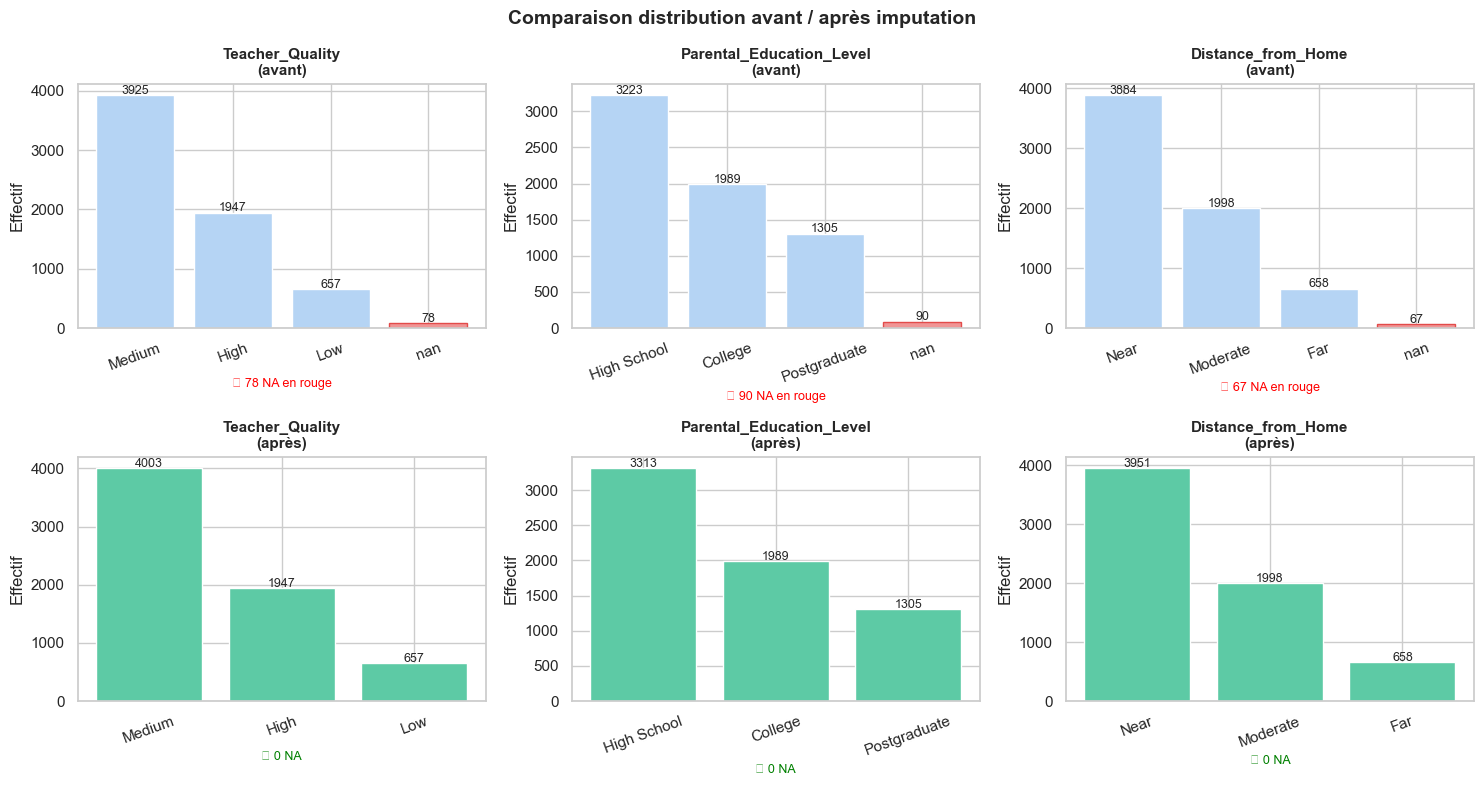


✅ Figure sauvegardée : imputation_avant_apres.png


In [15]:

# ══════════════════════════════════════════════════════════
# ÉTAPE 4 — Visualisation avant / après (comparaison)
# ══════════════════════════════════════════════════════════
df_original = pd.read_csv("StudentPerformanceFactors.csv")

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle("Comparaison distribution avant / après imputation",
             fontsize=14, fontweight="bold")

colors_before = "#B5D4F4"
colors_after  = "#5DCAA5"

for i, col in enumerate(cols_na):

    # ── Avant (ligne du haut) ──────────────────────────────
    ax_before = axes[0, i]
    counts_before = df_original[col].value_counts(dropna=False)
    labels = [str(x) for x in counts_before.index]
    bars = ax_before.bar(labels, counts_before.values,
                         color=colors_before, edgecolor="white")

    # Mettre en évidence la barre NaN
    for j, lbl in enumerate(labels):
        if lbl == "nan":
            bars[j].set_color("#F09595")
            bars[j].set_edgecolor("#E24B4A")

    for bar, val in zip(bars, counts_before.values):
        ax_before.text(bar.get_x() + bar.get_width()/2,
                       bar.get_height() + 20,
                       str(val), ha="center", fontsize=9)

    ax_before.set_title(f"{col}\n(avant)", fontsize=11, fontweight="bold")
    ax_before.set_ylabel("Effectif")
    ax_before.tick_params(axis="x", rotation=20)
    n_na = df_original[col].isna().sum()
    ax_before.set_xlabel(f"⚠ {n_na} NA en rouge", fontsize=9, color="red")

    # ── Après (ligne du bas) ───────────────────────────────
    ax_after = axes[1, i]
    counts_after = df[col].value_counts()
    ax_after.bar(counts_after.index.astype(str), counts_after.values,
                 color=colors_after, edgecolor="white")

    for bar, val in zip(ax_after.patches, counts_after.values):
        ax_after.text(bar.get_x() + bar.get_width()/2,
                      bar.get_height() + 20,
                      str(val), ha="center", fontsize=9)

    ax_after.set_title(f"{col}\n(après)", fontsize=11, fontweight="bold")
    ax_after.set_ylabel("Effectif")
    ax_after.tick_params(axis="x", rotation=20)
    ax_after.set_xlabel("✅ 0 NA", fontsize=9, color="green")

plt.tight_layout()
plt.savefig("imputation_avant_apres.png", dpi=150, bbox_inches="tight")
plt.show()
print("\n✅ Figure sauvegardée : imputation_avant_apres.png")



In [16]:
# ══════════════════════════════════════════════════════════
# ÉTAPE 5 — Sauvegarde du dataset propre
# ══════════════════════════════════════════════════════════
df.to_csv("StudentPerformanceFactors_clean.csv", index=False)

print("\n" + "=" * 55)
print("DATASET PROPRE SAUVEGARDÉ")
print("=" * 55)
print(f"  Fichier  : StudentPerformanceFactors_clean.csv")
print(f"  Lignes   : {df.shape[0]}")
print(f"  Colonnes : {df.shape[1]}")
print(f"  NA total : {df.isnull().sum().sum()}")
print("\n✅ Tâche 4 terminée — dataset prêt pour l'encodage (Tâche 5)")


DATASET PROPRE SAUVEGARDÉ
  Fichier  : StudentPerformanceFactors_clean.csv
  Lignes   : 6607
  Colonnes : 20
  NA total : 0

✅ Tâche 4 terminée — dataset prêt pour l'encodage (Tâche 5)
